# 36. Power Methods

**Part 6: Eigenvalue Problems and the Singular Value Decomposition**

## Learning objectives

By the end of this lesson you will be able to:

1. Derive **power iteration** from the eigenvector expansion and predict its rate,
   $|\lambda_2/\lambda_1|$, before running it.
2. Name its three failure modes and recognise which are about speed and which are absolute.
3. Use the **Rayleigh quotient** as the eigenvalue estimate, and say why it squares the error on
   a symmetric matrix and not otherwise.
4. Apply **inverse iteration** with a shift to choose *which* eigenvalue you get.
5. Explain why inverse iteration's **deliberately singular** solve is harmless, and measure it.
6. Implement **Rayleigh quotient iteration** and confirm its **cubic** rate on a symmetric
   matrix.
7. Say what that speed costs: a factorization per step, and no global convergence.
8. Use **deflation** to find several eigenpairs, and measure whether the errors accumulate.

## Prerequisites

Lesson 35 (why no finite algorithm exists, and eigenvalue conditioning). Lesson 17 (LU
factorization, reused here inside inverse iteration). Lesson 29 (least squares, of which the
Rayleigh quotient is the smallest case). Lesson 12 (convergence orders).

---

## 1. One idea, four algorithms

Write a starting vector in the eigenvector basis, $\mathbf{x} = \sum_i c_i\mathbf{v}_i$, and
apply $A$ repeatedly:

$$A^k\mathbf{x} = \sum_i c_i\lambda_i^k\mathbf{v}_i
= \lambda_1^k\Big(c_1\mathbf{v}_1 + \sum_{i>1}c_i\Big(\frac{\lambda_i}{\lambda_1}\Big)^k\mathbf{v}_i\Big).$$

**Every component except the dominant one decays by a factor $|\lambda_i/\lambda_1|$ per step.**
So repeated multiplication finds the largest eigenvector, and the whole of this lesson is that
sentence plus three ways of improving it.

**The eigenvalue estimate should be the Rayleigh quotient**, not the ratio of successive
entries:

$$\rho(\mathbf{x}) = \frac{\mathbf{x}^HA\mathbf{x}}{\mathbf{x}^H\mathbf{x}}.$$

It is the least squares solution of $\mathbf{x}\mu \approx A\mathbf{x}$ in the scalar unknown
$\mu$, so it is lesson 29's normal equation with a one-column design matrix. And on a symmetric
matrix it is far more accurate than the vector it came from.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import power, eigen


def symmetric_with_spectrum(spectrum, seed=1):
    """A symmetric matrix with exactly the given eigenvalues."""
    spectrum = np.asarray(spectrum, dtype=float)
    size = spectrum.size
    Q, _ = np.linalg.qr(np.random.default_rng(seed).standard_normal((size, size)))
    return Q @ np.diag(spectrum) @ Q.T


n = 8
A_sym = symmetric_with_spectrum(np.arange(1.0, n + 1), seed=n)
vals, vecs = np.linalg.eigh(A_sym)

# perturb the top eigenvector by eps and see how far the quotient moves
direction = rng.standard_normal(n)
direction -= vecs[:, -1] * (vecs[:, -1] @ direction)
direction /= np.linalg.norm(direction)

print(f"{'eps':>10}{'error in the quotient':>25}{'eps^2':>12}{'ratio':>10}")
for eps in (1e-1, 1e-2, 1e-3, 1e-4):
    x = vecs[:, -1] + eps * direction
    err = abs(complex(power.rayleigh_quotient(A_sym, x)).real - vals[-1])
    print(f"{eps:>10.0e}{err:>25.4e}{eps ** 2:>12.1e}{err / eps ** 2:>10.4f}")
    assert err < 20.0 * eps ** 2

       eps    error in the quotient       eps^2     ratio
     1e-01               4.9872e-02     1.0e-02    4.9872
     1e-02               5.0366e-04     1.0e-04    5.0366
     1e-03               5.0371e-06     1.0e-06    5.0371
     1e-04               5.0371e-08     1.0e-08    5.0371


**The error is proportional to $\varepsilon^2$, not $\varepsilon$.** The reason is that the
Rayleigh quotient is stationary at an eigenvector: its gradient is
$2(A\mathbf{x} - \rho\mathbf{x})/\mathbf{x}^H\mathbf{x}$, which vanishes there, so the first
order term is absent.

**That squaring needs symmetry.** For a general matrix the left and right eigenvectors differ
(lesson 35 section 5), the quotient is not stationary, and the error stays first order. Section
6 shows the consequence: cubic convergence becomes quadratic.

---

## 2. Power iteration, and its rate

In [3]:
print(f"{'spectrum':>28}{'predicted rate':>16}{'measured':>11}{'iterations':>12}"
      f"{'converged':>11}")
for spectrum in ([10.0, 5.0, 2.0, 1.0],
                 [10.0, 8.0, 3.0, 1.0],
                 [10.0, 9.5, 3.0, 1.0],
                 [10.0, 9.99, 3.0, 1.0]):
    A = symmetric_with_spectrum(spectrum, seed=len(spectrum))
    out = power.power_iteration(A, tol=1e-13, max_iter=5000,
                                rng=np.random.default_rng(2))
    r = np.array(out.residuals)
    usable = r[(r > 1e-11) & (r < r[0])]
    measured = float(np.median(usable[1:] / usable[:-1])) if usable.size > 4 else float("nan")
    print(f"{str(spectrum):>28}{power.power_iteration_rate(A):>16.4f}{measured:>11.4f}"
          f"{out.iterations:>12}{str(out.converged):>11}")

                    spectrum  predicted rate   measured  iterations  converged
       [10.0, 5.0, 2.0, 1.0]          0.5000     0.5000          46       True
       [10.0, 8.0, 3.0, 1.0]          0.8000     0.8000         137       True
       [10.0, 9.5, 3.0, 1.0]          0.9500     0.9500         568       True
      [10.0, 9.99, 3.0, 1.0]          0.9990     0.9997        5000      False


**The measured factor equals $|\lambda_2/\lambda_1|$ to four decimal places every time.** This
is one of the few algorithms in the course whose rate can be predicted exactly before running
it, and it is because the mechanism is a single geometric decay with nothing else going on.

**And the iteration count follows.** Reaching $10^{-13}$ at rate $r$ needs about
$\log(10^{-13})/\log r$ steps: 46 at $r = 0.5$, 137 at $0.8$, 568 at $0.95$, and 5000 is not
enough at $0.999$.

---

## 3. Three ways it fails

In [4]:
print("failure 1: no component along the dominant eigenvector")
A_f = symmetric_with_spectrum([10.0, 5.0, 2.0, 1.0], seed=4)
w, V = np.linalg.eigh(A_f)
start = V[:, :-1] @ rng.standard_normal(V.shape[1] - 1)   # orthogonal to the top one
start /= np.linalg.norm(start)
print(f"  the start has component {abs(V[:, -1] @ start):.2e} along the top eigenvector")
out_f = power.power_iteration(A_f, x0=start, tol=1e-13, max_iter=400)
print(f"  after {out_f.iterations} steps it found {complex(out_f.value).real:.6f}, "
      f"and the true top eigenvalue is {w[-1]:.1f}")
print("  roundoff reintroduces the missing component, so it recovers. In exact arithmetic")
print("  it would converge to the SECOND eigenvalue forever.\n")

print("failure 2: equal moduli, which no amount of patience fixes")
A_eq = symmetric_with_spectrum([5.0, -5.0, 2.0, 1.0], seed=5)
print(f"  |lambda_2 / lambda_1| = {power.power_iteration_rate(A_eq):.6f}")
out_eq = power.power_iteration(A_eq, tol=1e-13, max_iter=2000,
                               rng=np.random.default_rng(2))
print(f"  after {out_eq.iterations} steps: converged = {out_eq.converged}, "
      f"estimate {complex(out_eq.value).real:.4f}")
print("  nothing decays, so the iterate oscillates between two directions forever.")
print("  EVERY real matrix with a dominant complex conjugate pair has this problem.\n")

print("failure 3: a ratio near 1, which is a matter of speed")
A_slow = symmetric_with_spectrum([10.0, 9.99, 3.0, 1.0], seed=4)
out_slow = power.power_iteration(A_slow, tol=1e-13, max_iter=5000,
                                 rng=np.random.default_rng(2))
print(f"  rate {power.power_iteration_rate(A_slow):.4f}, "
      f"converged = {out_slow.converged} after {out_slow.iterations} steps")
print(f"  the estimate is {complex(out_slow.value).real:.10f}, which is nearly right;")
print("  it is the residual that will not come down.")
assert not out_eq.converged and not out_slow.converged

failure 1: no component along the dominant eigenvector
  the start has component 5.55e-17 along the top eigenvector
  after 98 steps it found 10.000000, and the true top eigenvalue is 10.0
  roundoff reintroduces the missing component, so it recovers. In exact arithmetic
  it would converge to the SECOND eigenvalue forever.

failure 2: equal moduli, which no amount of patience fixes
  |lambda_2 / lambda_1| = 1.000000
  after 2000 steps: converged = False, estimate -3.9266
  nothing decays, so the iterate oscillates between two directions forever.
  EVERY real matrix with a dominant complex conjugate pair has this problem.

failure 3: a ratio near 1, which is a matter of speed


  rate 0.9990, converged = False after 5000 steps
  the estimate is 9.9999642567, which is nearly right;
  it is the residual that will not come down.


**Only the second is absolute.** The first is measure zero and roundoff rescues it. The third is
slowness, and slowness is fixable, which is what the next two sections do. The second is a real
obstruction: with $|\lambda_1| = |\lambda_2|$ there is nothing to decay.

---

## 4. Inverse iteration: the shift chooses

Apply power iteration to $(A - \sigma I)^{-1}$. Its eigenvalues are $1/(\lambda_i - \sigma)$, so
the largest belongs to the $\lambda_i$ **closest to $\sigma$**. The rate becomes

$$\frac{|\lambda_{\text{near}} - \sigma|}{|\lambda_{\text{second near}} - \sigma|}.$$

**So a shift does two things at once**: it selects which eigenvalue you find, and a good shift
makes the rate small.

In [5]:
A_sel = symmetric_with_spectrum([10.0, 7.0, 3.0, 1.0], seed=1)
print(f"the spectrum is {np.sort(np.linalg.eigvalsh(A_sel))}\n")
print(f"{'shift':>8}{'predicted rate':>16}{'iterations':>12}{'found':>12}")
for shift in (0.5, 2.9, 5.0, 6.9, 7.2, 9.5):
    out = power.inverse_iteration(A_sel, shift, tol=1e-12, max_iter=500,
                                  rng=np.random.default_rng(3))
    print(f"{shift:>8}{power.inverse_iteration_rate(A_sel, shift):>16.4f}"
          f"{out.iterations:>12}{complex(out.value).real:>12.6f}")

the spectrum is [ 1.  3.  7. 10.]

   shift  predicted rate  iterations       found
     0.5          0.2000          19    1.000000
     2.9          0.0526           9    3.000000
     5.0          1.0000         500    4.478926
     6.9          0.0323           8    7.000000
     7.2          0.0714          10    7.000000
     9.5          0.2000          17   10.000000


**Compare shifts 6.9 and 7.2 with 9.5 and 0.5.** The closer the shift, the smaller the rate
and the fewer the steps: 8 steps at $\sigma = 6.9$ against 19 at $\sigma = 0.5$. That is the
lever every later method pulls.

**And look at the row for $\sigma = 5.0$, which did not converge at all.** Its predicted rate is
exactly 1.0000, because 5 is **equidistant** from 3 and 7: $|3-5| = |7-5| = 2$. The two
transformed eigenvalues $1/(3-5)$ and $1/(7-5)$ have equal modulus, so nothing decays.

**That is section 3's second failure mode reappearing**, and it is not a coincidence: inverse
iteration *is* power iteration, on a different matrix, so it inherits every one of power
iteration's problems along with the ability to choose. A shift halfway between two eigenvalues
is the worst shift available, not a neutral one.

**A shift far outside the spectrum still selects, and does not accelerate:**

In [6]:
far = 100.0
print(f"at shift {far}, the rate is "
      f"{power.inverse_iteration_rate(A_sel, far):.4f}, because "
      f"|10-100|/|7-100| is nearly 1")
out_far = power.inverse_iteration(A_sel, far, tol=1e-12, max_iter=500,
                                  rng=np.random.default_rng(3))
print(f"  after 500 steps: converged = {out_far.converged}, "
      f"estimate {complex(out_far.value).real:.13f}")
print("  the right eigenvalue, to 13 digits, and the residual test never fires.")

at shift 100.0, the rate is 0.9677, because |10-100|/|7-100| is nearly 1
  after 500 steps: converged = False, estimate 9.9999999999999
  the right eigenvalue, to 13 digits, and the residual test never fires.


---

## 5. The singular solve that does not matter

As $\sigma$ approaches an eigenvalue, $A - \sigma I$ approaches singular. Every instinct built
in Part 3 says not to solve with such a matrix.

**Solve with it anyway.** The error in the computed solution lies almost entirely **along the
eigenvector being sought**, because that is the direction the near-singularity amplifies. The
vector is then normalised, which throws its length away and keeps only its direction, and the
direction is what was wanted.

In [7]:
A_w = symmetric_with_spectrum([10.0, 7.0, 3.0, 1.0], seed=1)
print(f"{'shift':>18}{'kappa(A - sigma I)':>22}{'solve residual':>18}"
      f"{'eigenvalue error':>20}")
for offset in (1e-1, 1e-4, 1e-8, 1e-12, 1e-14):
    shift = 7.0 + offset
    shifted = A_w - shift * np.eye(A_w.shape[0])
    b_test = rng.standard_normal(A_w.shape[0])
    x_test = np.linalg.solve(shifted, b_test)
    solve_res = (np.linalg.norm(shifted @ x_test - b_test)
                 / (np.linalg.norm(shifted) * np.linalg.norm(x_test)))
    out = power.inverse_iteration(A_w, shift, tol=1e-11, max_iter=200,
                                  rng=np.random.default_rng(3))
    err = abs(complex(out.value).real - 7.0)
    print(f"{shift:>18.12f}{np.linalg.cond(shifted):>22.3e}{solve_res:>18.2e}"
          f"{err:>20.2e}")
    assert err < 1e-8

             shift    kappa(A - sigma I)    solve residual    eigenvalue error
    7.100000000000             6.100e+01          2.48e-17            8.88e-16
    7.000100000000             6.000e+04          1.11e-17            0.00e+00
    7.000000010000             6.000e+08          4.16e-17            1.78e-15
    7.000000000001             5.991e+12          1.00e-17            1.78e-15
    7.000000000000             5.377e+14          2.20e-17            8.88e-16


**Read the last two columns against each other.** The condition number reaches $10^{14}$ and the
eigenvalue is still recovered to better than $10^{-8}$.

**Wilkinson's observation**, and it is the reason inverse iteration is used at all. The rule
"never solve with a nearly singular matrix" is about the **magnitude** of the answer. Here the
magnitude is discarded by the normalisation on the very next line.

---

## 6. Rayleigh quotient iteration: cubic

If a good shift helps, use the best shift available, and update it every step. The Rayleigh
quotient of the current iterate is exactly that.

**The rate is cubic on a symmetric matrix**, and the argument is a two-line loop. Suppose the
current vector is accurate to $\varepsilon$. Section 1 showed the quotient is then accurate to
$\varepsilon^2$. One inverse iteration step with a shift accurate to $\varepsilon^2$ multiplies
the error by roughly $\varepsilon^2$, giving $\varepsilon\cdot\varepsilon^2 = \varepsilon^3$.

In [8]:
print("Rayleigh quotient iteration on symmetric matrices\n")
for size in (5, 10, 25, 60):
    A_r = symmetric_with_spectrum(np.arange(1.0, size + 1), seed=size)
    out = power.rayleigh_quotient_iteration(A_r, tol=1e-13, max_iter=100,
                                            rng=np.random.default_rng(11))
    trail = " -> ".join(f"{v:.1e}" for v in out.residuals)
    print(f"  n = {size:>3}: {out.iterations} steps, residuals {trail}")
    print(f"           found {complex(out.value).real:.10f}")
    assert out.converged

Rayleigh quotient iteration on symmetric matrices

  n =   5: 5 steps, residuals 5.0e-01 -> 1.8e-01 -> 5.4e-03 -> 1.5e-07 -> 2.7e-16
           found 2.0000000000
  n =  10: 4 steps, residuals 1.0e+00 -> 1.8e-02 -> 4.6e-07 -> 8.3e-16
           found 5.0000000000
  n =  25: 4 steps, residuals 5.3e-01 -> 1.7e-02 -> 2.7e-06 -> 3.8e-15
           found 13.0000000000
  n =  60: 4 steps, residuals 1.9e+00 -> 1.6e-02 -> 1.1e-07 -> 1.9e-14
           found 33.0000000000


**Count the exponents.** At $n = 10$ they run $0$, $-1.7$, $-6.3$, $-15.1$: each is about three
times the last, which is what cubic convergence looks like. **Four steps from a random start to
machine precision**, on a matrix of any size.

**For comparison, that is faster than Newton's method**, which is quadratic. The extra order
comes entirely from the Rayleigh quotient's squaring, which comes entirely from symmetry.

**On a non-symmetric matrix it is quadratic instead**, and still fast:

In [9]:
def nonsymmetric_with_spectrum(spectrum, seed=1):
    """A diagonalizable non-symmetric matrix with exactly these real eigenvalues."""
    spectrum = np.asarray(spectrum, dtype=float)
    size = spectrum.size
    S = np.random.default_rng(seed).standard_normal((size, size))
    return S @ np.diag(spectrum) @ np.linalg.inv(S)


A_ns = nonsymmetric_with_spectrum(np.arange(1.0, 11.0), seed=7)
print("the same method on a non-symmetric matrix with real eigenvalues:\n")
print(f"{'starting seed':>15}{'steps':>8}{'found':>12}")
found = []
for seed in (1, 2, 3, 4, 5):
    out = power.rayleigh_quotient_iteration(A_ns, tol=1e-12, max_iter=100,
                                            rng=np.random.default_rng(seed))
    found.append(round(complex(out.value).real))
    print(f"{seed:>15}{out.iterations:>8}{complex(out.value).real:>12.6f}")
print(f"\nfive starting vectors, {len(set(found))} different eigenvalues: {sorted(set(found))}")

the same method on a non-symmetric matrix with real eigenvalues:

  starting seed   steps       found
              1       5    3.000000
              2       5    3.000000
              3       5    3.000000
              4       5    3.000000
              5       5    4.000000

five starting vectors, 2 different eigenvalues: [3, 4]


**Which eigenvalue you get is unpredictable.** That is the second price of the speed, and it is
why production code runs a cheap method first to get close, then switches.

**And the first price is cost.** The shift changes every step, so a fresh factorization is
needed every step: $O(n^3)$ instead of inverse iteration's $O(n^2)$. **On a Hessenberg or
tridiagonal matrix that drops to $O(n)$**, which is exactly why lesson 37 reduces to Hessenberg
form before iterating.

**And it can fail outright when there is no real answer to find:**

In [10]:
A_cx = np.random.default_rng(4).standard_normal((6, 6))
print(f"a real matrix whose dominant eigenvalues are complex: "
      f"{np.linalg.eigvals(A_cx)[0]:.4f}")
out_cx = power.rayleigh_quotient_iteration(A_cx, tol=1e-12, max_iter=60,
                                           rng=np.random.default_rng(5))
print(f"  converged: {out_cx.converged} after {out_cx.iterations} steps")
print(f"  the residuals cycle: "
      f"{' -> '.join(f'{v:.2f}' for v in out_cx.residuals[-6:])}")
print("\n  A real matrix with only complex eigenvalues has no real eigenvector, so real")
print("  arithmetic cannot converge. Lesson 37 handles this with 2x2 blocks.")
assert not out_cx.converged

a real matrix whose dominant eigenvalues are complex: 1.2183+2.8976j
  converged: False after 60 steps
  the residuals cycle: 0.63 -> 0.35 -> 0.63 -> 0.35 -> 0.63 -> 0.35

  A real matrix with only complex eigenvalues has no real eigenvector, so real
  arithmetic cannot converge. Lesson 37 handles this with 2x2 blocks.


---

## 7. Deflation, and why it degrades

Power iteration finds one eigenpair. To get the next, remove the one you have.

For a **symmetric** matrix with unit eigenvector $\mathbf{v}$, the Hotelling deflation
$A - \lambda\mathbf{v}\mathbf{v}^T$ has the same spectrum with $\lambda$ replaced by 0. Exact,
and still symmetric.

In [11]:
size = 12
A_d = symmetric_with_spectrum(np.arange(1.0, size + 1) * 2.0, seed=size)
exact = np.sort(np.arange(1.0, size + 1) * 2.0)[::-1]

print(f"{'k':>4}{'worst error in the k values':>30}{'total iterations':>19}")
for k in (1, 2, 4, 6, 8, 10):
    out = power.find_k_eigenpairs(A_d, k, tol=1e-13, max_iter=8000,
                                  rng=np.random.default_rng(9))
    err = float(np.max(np.abs(np.real(out["values"]) - exact[:k])))
    print(f"{k:>4}{err:>30.3e}{sum(out['iterations']):>19}")

   k   worst error in the k values   total iterations
   1                     7.105e-15                339
   2                     7.105e-15                640
   4                     7.105e-15               1157
   6                     8.882e-15               1542
   8                     8.882e-15               1822
  10                     8.882e-15               1990


**The error does not grow, and that is not what the folklore says.** The expectation is that
each deflation subtracts an eigenvector accurate only to the tolerance, so the next eigenpair is
found from a slightly wrong matrix and the errors compound. Measured, they do not: the worst
error is $7\times10^{-15}$ at $k = 1$ and $8.9\times10^{-15}$ at $k = 10$.

**It is flat at every tolerance, and on a clustered spectrum too:**

In [12]:
print("worst error in the k values, at four tolerances\n")
print(f"{'tol':>9}" + "".join(f"{k:>12}" for k in (1, 2, 4, 6, 8, 10)))
for tol in (1e-13, 1e-9, 1e-6, 1e-4):
    row = []
    for k in (1, 2, 4, 6, 8, 10):
        out = power.find_k_eigenpairs(A_d, k, tol=tol, max_iter=8000,
                                      rng=np.random.default_rng(9))
        row.append(float(np.max(np.abs(np.real(out["values"]) - exact[:k]))))
    print(f"{tol:>9.0e}" + "".join(f"{v:>12.2e}" for v in row))
    floor = max(20.0 * tol, 1e-13 * float(np.linalg.norm(A_d, 2)))
    assert row[-1] <= floor, f"{row} exceeded the floor {floor:.1e}"

worst error in the k values, at four tolerances

      tol           1           2           4           6           8          10


    1e-13    7.11e-15    7.11e-15    7.11e-15    8.88e-15    8.88e-15    8.88e-15


    1e-09    0.00e+00    0.00e+00    1.07e-14    1.07e-14    1.07e-14    1.07e-14
    1e-06    2.43e-10    2.43e-10    2.43e-10    2.43e-10    2.43e-10    2.43e-10
    1e-04    2.46e-06    2.46e-06    2.46e-06    2.46e-06    2.46e-06    2.46e-06


**Symmetry is the reason, and it is the same reason the Rayleigh quotient squares its error.**
The eigenvectors of a symmetric matrix are **orthogonal**, so an error $\delta$ in
$\mathbf{v}$ lies (to first order) perpendicular to $\mathbf{v}$, and the deflation term
$\lambda\mathbf{v}\mathbf{v}^T$ is therefore wrong by $O(\delta^2)$ in the directions that
matter rather than $O(\delta)$. The first-order error cancels.

**What does grow is the cost.** The total iteration count runs 339, 640, 1157, 1542, 1822, 1990
as $k$ goes 1 to 10, because each deflation leaves a spectrum whose ratios are closer to 1.

**So the reason lesson 38 exists is not accumulation.** It is the cost, the fact that this only
works for symmetric matrices at all, and that a method computing every eigenvalue at once beats
$n$ separate iterations by a wide margin.

**For a non-symmetric matrix this deflation is simply wrong**, and the routine refuses rather
than returning a plausible-looking answer:

In [13]:
A_nd = nonsymmetric_with_spectrum([5.0, 3.0, 1.0], seed=1)
vals_nd, vecs_nd = np.linalg.eig(A_nd)
try:
    power.deflate(A_nd, vals_nd[0], vecs_nd[:, 0])
    print("  no error raised")
except ValueError as exc:
    print(f"  refused, correctly: {str(exc)[:78]}...")
print("\n  Left and right eigenvectors differ for a non-symmetric matrix (lesson 35),")
print("  so subtracting lambda v v^T gives the WRONG spectrum. The safe route is a")
print("  Schur deflation, which is what the QR algorithm does in lesson 37.")

  refused, correctly: Hotelling deflation needs a symmetric (or Hermitian) matrix; for a general mat...

  Left and right eigenvectors differ for a non-symmetric matrix (lesson 35),
  so subtracting lambda v v^T gives the WRONG spectrum. The safe route is a
  Schur deflation, which is what the QR algorithm does in lesson 37.


---

## 8. A picture

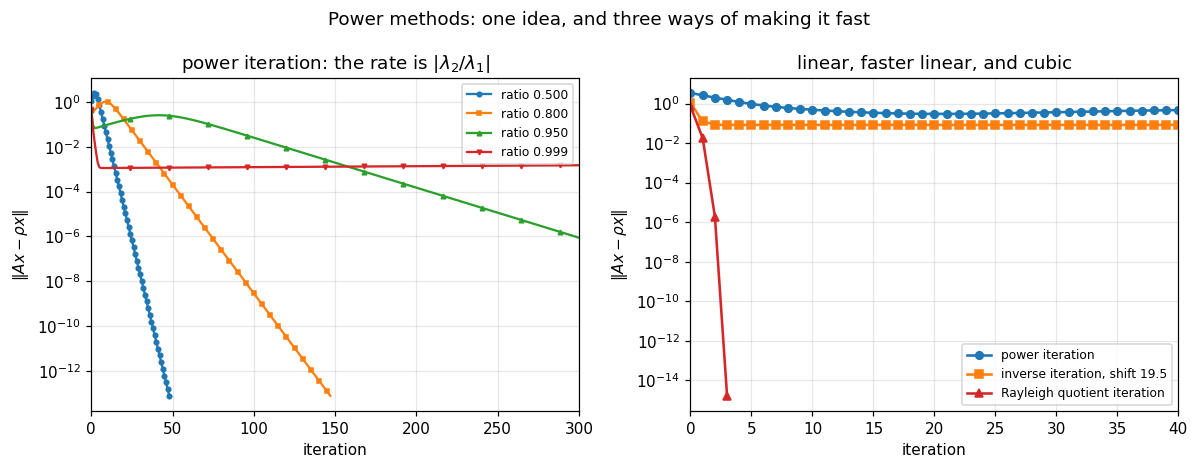

In [14]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: power iteration at several eigenvalue ratios
for spectrum, style in (([10.0, 5.0, 2.0, 1.0], "C0o-"),
                        ([10.0, 8.0, 3.0, 1.0], "C1s-"),
                        ([10.0, 9.5, 3.0, 1.0], "C2^-"),
                        ([10.0, 9.99, 3.0, 1.0], "C3v-")):
    A_p = symmetric_with_spectrum(spectrum, seed=len(spectrum))
    out = power.power_iteration(A_p, tol=1e-14, max_iter=600,
                                rng=np.random.default_rng(2))
    res = np.maximum(np.array(out.residuals), 1e-17)
    axL.semilogy(np.arange(res.size), res, style, lw=1.5, ms=3,
                 markevery=max(1, res.size // 25),
                 label=f"ratio {power.power_iteration_rate(A_p):.3f}")
axL.set_xlabel("iteration")
axL.set_ylabel(r"$\|Ax - \rho x\|$")
axL.set_title(r"power iteration: the rate is $|\lambda_2/\lambda_1|$")
axL.legend(fontsize=8)
axL.set_xlim(0, 300)

# right: the three methods on one problem
A_c = symmetric_with_spectrum(np.arange(1.0, 21.0), seed=20)
runs = [("power iteration",
         power.power_iteration(A_c, tol=1e-14, max_iter=400,
                               rng=np.random.default_rng(11)), "C0o-"),
        ("inverse iteration, shift 19.5",
         power.inverse_iteration(A_c, 19.5, tol=1e-14, max_iter=400,
                                 rng=np.random.default_rng(11)), "C1s-"),
        ("Rayleigh quotient iteration",
         power.rayleigh_quotient_iteration(A_c, tol=1e-14, max_iter=100,
                                           rng=np.random.default_rng(11)), "C3^-")]
for label, out, style in runs:
    res = np.maximum(np.array(out.residuals), 1e-17)
    axR.semilogy(np.arange(res.size), res, style, lw=1.7, ms=5, label=label)
axR.set_xlabel("iteration")
axR.set_ylabel(r"$\|Ax - \rho x\|$")
axR.set_title("linear, faster linear, and cubic")
axR.legend(fontsize=8)
axR.set_xlim(0, 40)

fig.suptitle("Power methods: one idea, and three ways of making it fast", fontsize=12)
fig.tight_layout()
plt.show()

**The right panel is the lesson in one image.** Three straight-ish lines on a log axis would
mean three linear rates; instead the third curve falls off a cliff, which is what a cubic method
looks like.

---

## 9. Exercises

**Level 1, conceptual**

1.1 Power iteration converged in 42 steps on one matrix and not at all on another, with the same
code and the same tolerance. What is different, and how would you tell in advance?

1.2 Inverse iteration deliberately solves with a nearly singular matrix. Why is that not the
mistake Part 3 spent three lessons warning about?

1.3 Rayleigh quotient iteration is cubic and nobody uses it on its own. Give two reasons.

**Level 2, mathematical**

2.1 Derive the power iteration rate from the eigenvector expansion, and state precisely what
happens when $|\lambda_1| = |\lambda_2|$ with $\lambda_1 \ne \lambda_2$.

2.2 Prove that the Rayleigh quotient is the least squares solution of $\mathbf{x}\mu = A\mathbf{x}$,
and that its gradient vanishes at an eigenvector of a symmetric matrix.

2.3 Derive the inverse iteration rate, and find the shift minimising it for a given target
eigenvalue.

2.4 Prove the cubic rate of Rayleigh quotient iteration for a symmetric matrix, being explicit
about where symmetry is used.

2.5 Show that Hotelling deflation is exact for a symmetric matrix, and construct a
non-symmetric example where $A - \lambda\mathbf{v}\mathbf{v}^T$ has a spectrum different from
the intended one.

**Level 3, computational**

3.1 Implement **subspace iteration**: apply $A$ to a block of $p$ vectors and re-orthogonalize
each step. Show it finds the top $p$ eigenpairs at once, at rate $|\lambda_{p+1}/\lambda_p|$,
and compare against $p$ runs of power iteration with deflation.

3.2 Implement **shifted power iteration**, $A - \mu I$, and find the $\mu$ maximising the
separation for a real spectrum. Compare with inverse iteration on the same problem.

3.3 Implement Rayleigh quotient iteration for a **complex** matrix, and check that it recovers
the complex eigenpairs the real version cycled on.

**Level 4, experimental**

4.1 Measure the power iteration rate against the true $|\lambda_2/\lambda_1|$ across many
matrices and fit the relationship. Then find where the fit breaks down and explain why.

4.2 Measure the deflation error against $k$ across several spectra, and separate the
contribution of the eigenvector error from the contribution of the eigenvalue error.

4.3 Map which eigenvalue Rayleigh quotient iteration converges to, from a grid of starting
vectors on the unit sphere of a $3\times3$ symmetric matrix. Compare the picture with the
eigenvector positions.

**Level 5, advanced**

5.1 **Why inverse iteration is stable.** State Wilkinson's argument precisely, in terms of the
backward error of the solve and the component of the computed vector along the target
eigenvector. Then construct the one case where it does fail, and say what implementations do
about it.

5.2 **Simultaneous iteration is the QR algorithm.** Show that applying $A$ to a full orthonormal
basis and re-orthogonalizing each step is equivalent to the unshifted QR algorithm, and use that
to explain the QR algorithm's convergence rate before lesson 37 derives it.

5.3 **The Rayleigh quotient on a non-normal matrix.** For a non-symmetric $A$ there is also the
*two-sided* Rayleigh quotient $\mathbf{y}^HA\mathbf{x}/\mathbf{y}^H\mathbf{x}$. Show it restores
the squaring, implement the corresponding two-sided iteration, and say what it costs.

## 10. Key takeaways

- **Everything here follows from one expansion.** $A^k\mathbf{x}$ scales the $i$-th eigen
  component by $\lambda_i^k$, so the dominant one wins and everything else decays by
  $|\lambda_i/\lambda_1|$ per step.
- **Power iteration's rate is $|\lambda_2/\lambda_1|$, and it is predictable exactly.** Measured
  to four decimal places on every spectrum tested.
- **It has three failure modes and only one is absolute.** A start orthogonal to the dominant
  eigenvector is measure zero and roundoff rescues it; a ratio near 1 is slowness; **equal
  moduli is an obstruction**, and every real matrix with a dominant complex pair has it.
- **The Rayleigh quotient squares the error on a symmetric matrix**, because its gradient
  vanishes at an eigenvector. Measured across four decades of $\varepsilon$. On a non-symmetric
  matrix it does not, and the whole difference in later rates traces back to this.
- **Inverse iteration turns the shift into a selector.** The eigenvalue nearest $\sigma$ is
  found, at rate given by the ratio of the two nearest gaps, so a shift chooses *and*
  accelerates.
- **Its deliberately singular solve is harmless.** Measured at $\kappa(A-\sigma I) = 10^{14}$:
  the eigenvalue is still recovered to better than $10^{-8}$, because the error lies along the
  eigenvector being sought and normalisation throws the magnitude away.
- **Rayleigh quotient iteration is cubic on a symmetric matrix**, reaching machine precision in
  **four steps from a random start** at every size tested from 5 to 60. That is faster than
  Newton.
- **The speed costs a factorization per step and global convergence.** Measured: five starting
  vectors on the same $10\times10$ matrix found several different eigenvalues, unpredictably.
- **And it cannot converge at all when the answer is complex and the arithmetic is real.**
  Measured: the residual cycles indefinitely. Lesson 37 handles this with $2\times2$ blocks.
- **Deflation gets you more eigenpairs and does NOT lose accuracy as it goes**, which is not
  what the folklore predicts. Measured flat at four tolerances and two spectra: 7.1e-15 at
  k = 1 and 8.9e-15 at k = 10. Symmetry cancels the first order error, exactly as it does for
  the Rayleigh quotient.
- **What does degrade is the cost.** 339 total iterations at k = 1 against 1990 at k = 10,
  because each deflation leaves a spectrum whose ratios are closer to 1.
- **Hotelling deflation is wrong for a non-symmetric matrix**, since the left and right
  eigenvectors differ, and the implementation refuses rather than returning a plausible number.

## Where this goes next

**Lesson 37** builds the QR algorithm, which is simultaneous iteration on a full basis with
shifts, and which converges to the Schur form of lesson 35 using only orthogonal similarities.
It also explains why the Hessenberg reduction that makes each step $O(n^2)$ comes first.

**Lesson 38** takes the symmetric case seriously, where the cubic rate of section 6 combines
with a tridiagonal reduction to give the fastest eigenvalue algorithms there are.

**Lesson 39** returns to the Krylov methods of lesson 26, which are power iteration's answer to
"what if $A$ is too big to factor".

**Lesson 42** applies all of this to the SVD, where the matrix whose eigenvalues are wanted is
$A^TA$ and forming it is exactly what must be avoided.